In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [65]:
stress_df = pd.read_csv('stress_data.csv')

In [66]:
print(stress_df.shape)

(843, 26)


In [67]:
stress_df.head()

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [68]:
stress_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 26 columns):
 #   Column                                                                Non-Null Count  Dtype 
---  ------                                                                --------------  ----- 
 0   Gender                                                                843 non-null    int64 
 1   Age                                                                   843 non-null    int64 
 2   Have you recently experienced stress in your life?                    843 non-null    int64 
 3   Have you noticed a rapid heartbeat or palpitations?                   843 non-null    int64 
 4   Have you been dealing with anxiety or tension recently?               843 non-null    int64 
 5   Do you face any sleep problems or difficulties falling asleep?        843 non-null    int64 
 6   Have you been dealing with anxiety or tension recently?.1             843 non-null    int64 
 7   Have you

In [69]:
stress_df.describe()

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Do you find that your relationship often causes you stress?,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?
count,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,...,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000
mean,0.349941,20.071174,2.997628,2.755635,2.543298,2.786477,2.663108,2.628707,2.702254,2.699881,...,2.514828,2.447212,2.488731,2.517200,2.424674,2.581257,2.641756,2.756821,3.258600,2.398577
std,0.477234,5.429502,1.134639,1.118650,1.201330,1.266959,1.266376,1.266593,1.314213,1.313673,...,1.241869,1.195995,1.196116,1.247563,1.256795,1.288163,1.305848,1.263008,1.202543,1.112485
min,0.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,19.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000
50%,0.000000,19.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000
75%,1.000000,20.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000
max,1.000000,100.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [70]:
stress_df.isnull().sum()

Gender                                                                  0
Age                                                                     0
Have you recently experienced stress in your life?                      0
Have you noticed a rapid heartbeat or palpitations?                     0
Have you been dealing with anxiety or tension recently?                 0
Do you face any sleep problems or difficulties falling asleep?          0
Have you been dealing with anxiety or tension recently?.1               0
Have you been getting headaches more often than usual?                  0
Do you get irritated easily?                                            0
Do you have trouble concentrating on your academic tasks?               0
Have you been feeling sadness or low mood?                              0
Have you been experiencing any illness or health issues?                0
Do you often feel lonely or isolated?                                   0
Do you feel overwhelmed with your acad

In [71]:
stress_df.duplicated().sum()


np.int64(27)

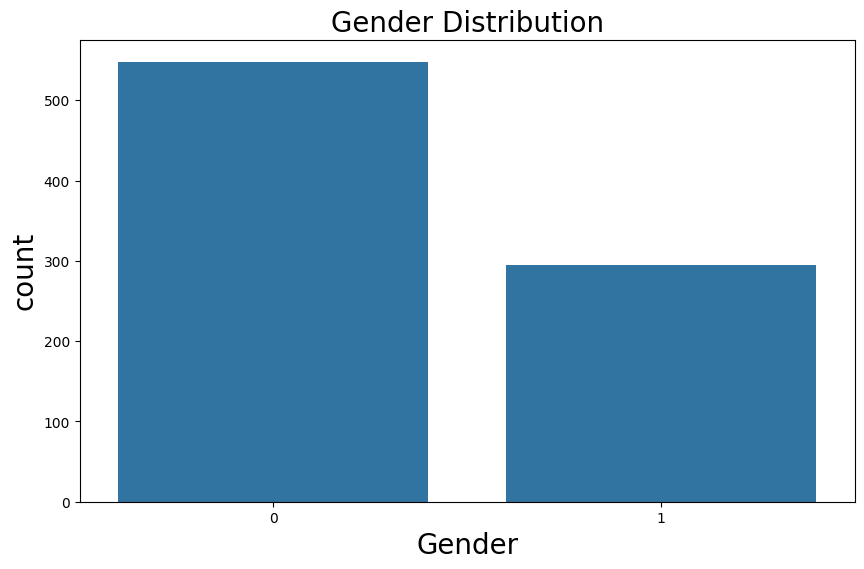

In [72]:
# Gender distribution
plt.figure(figsize=(10, 6))
sns.countplot(x="Gender", data=stress_df)
plt.xlabel('Gender',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.title("Gender Distribution",fontsize=20)
plt.show()


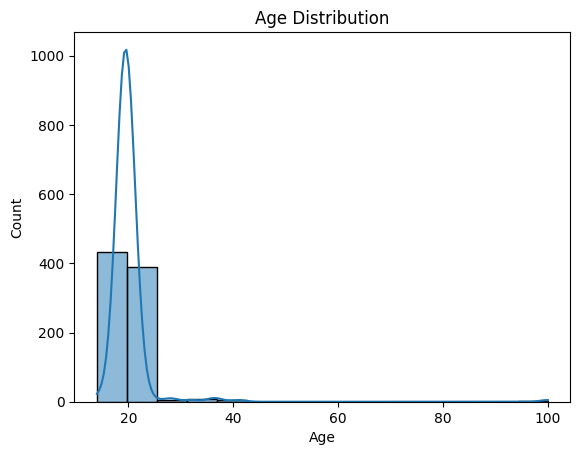

In [73]:
# Age distribution
sns.histplot(stress_df["Age"], bins=15, kde=True)
plt.title("Age Distribution")
plt.show()


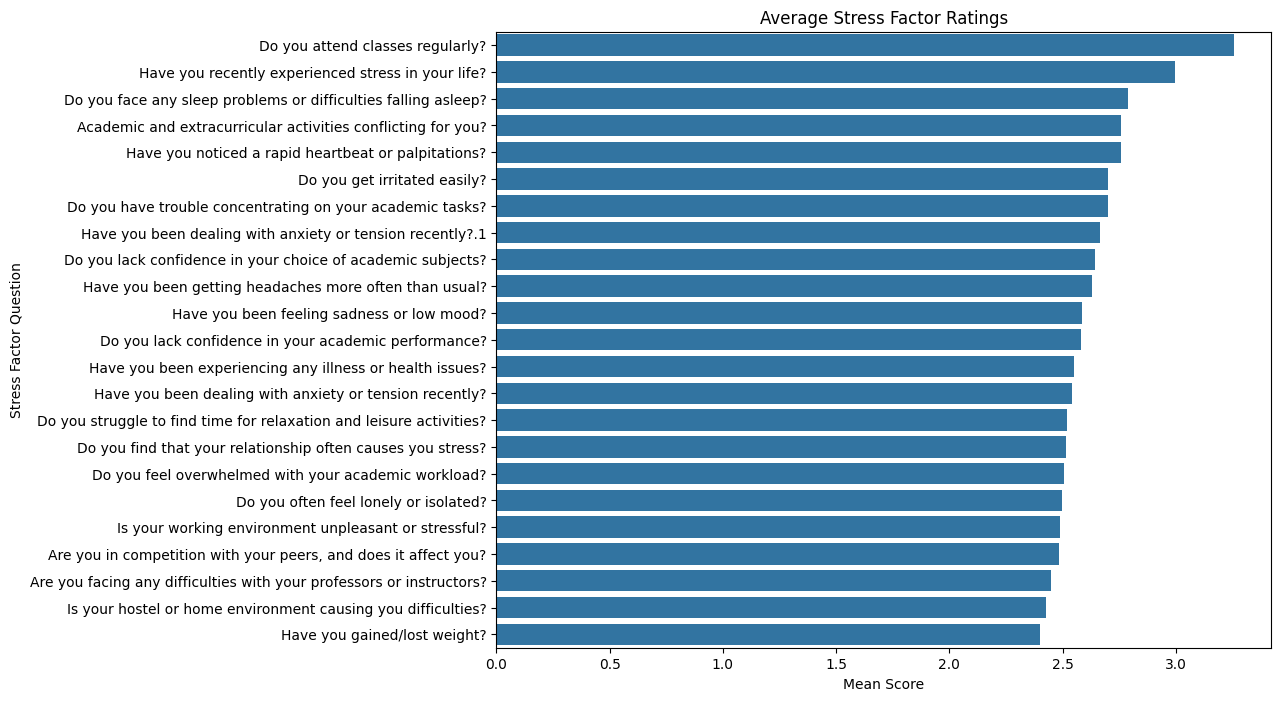

In [74]:
# Select only survey questions (exclude gender, age, stress type)
survey_cols = stress_df.columns[2:-1]

# Mean response per question
mean_scores = stress_df[survey_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=mean_scores.values, y=mean_scores.index)
plt.title("Average Stress Factor Ratings")
plt.xlabel("Mean Score")
plt.ylabel("Stress Factor Question")
plt.show()




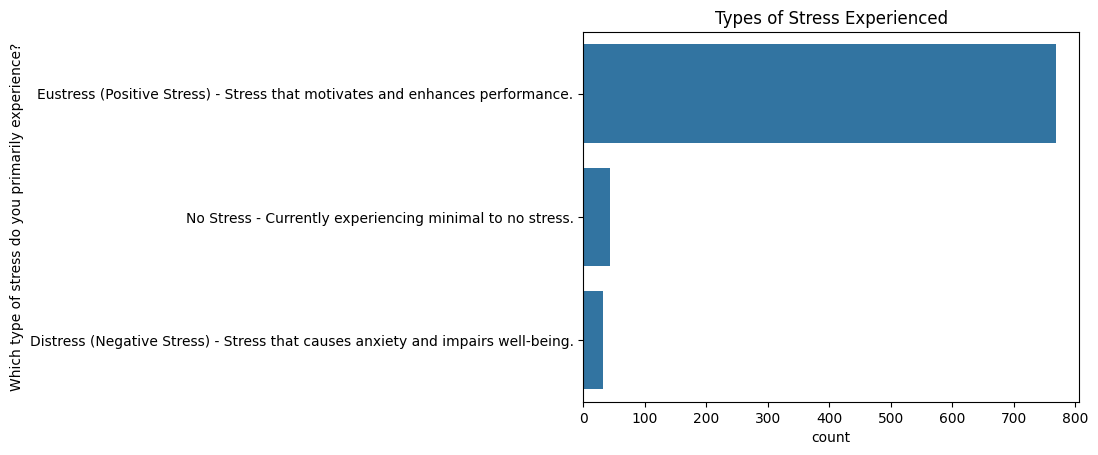

In [75]:
sns.countplot(y="Which type of stress do you primarily experience?", data=stress_df, order=stress_df["Which type of stress do you primarily experience?"].value_counts().index)
plt.title("Types of Stress Experienced")
plt.show()


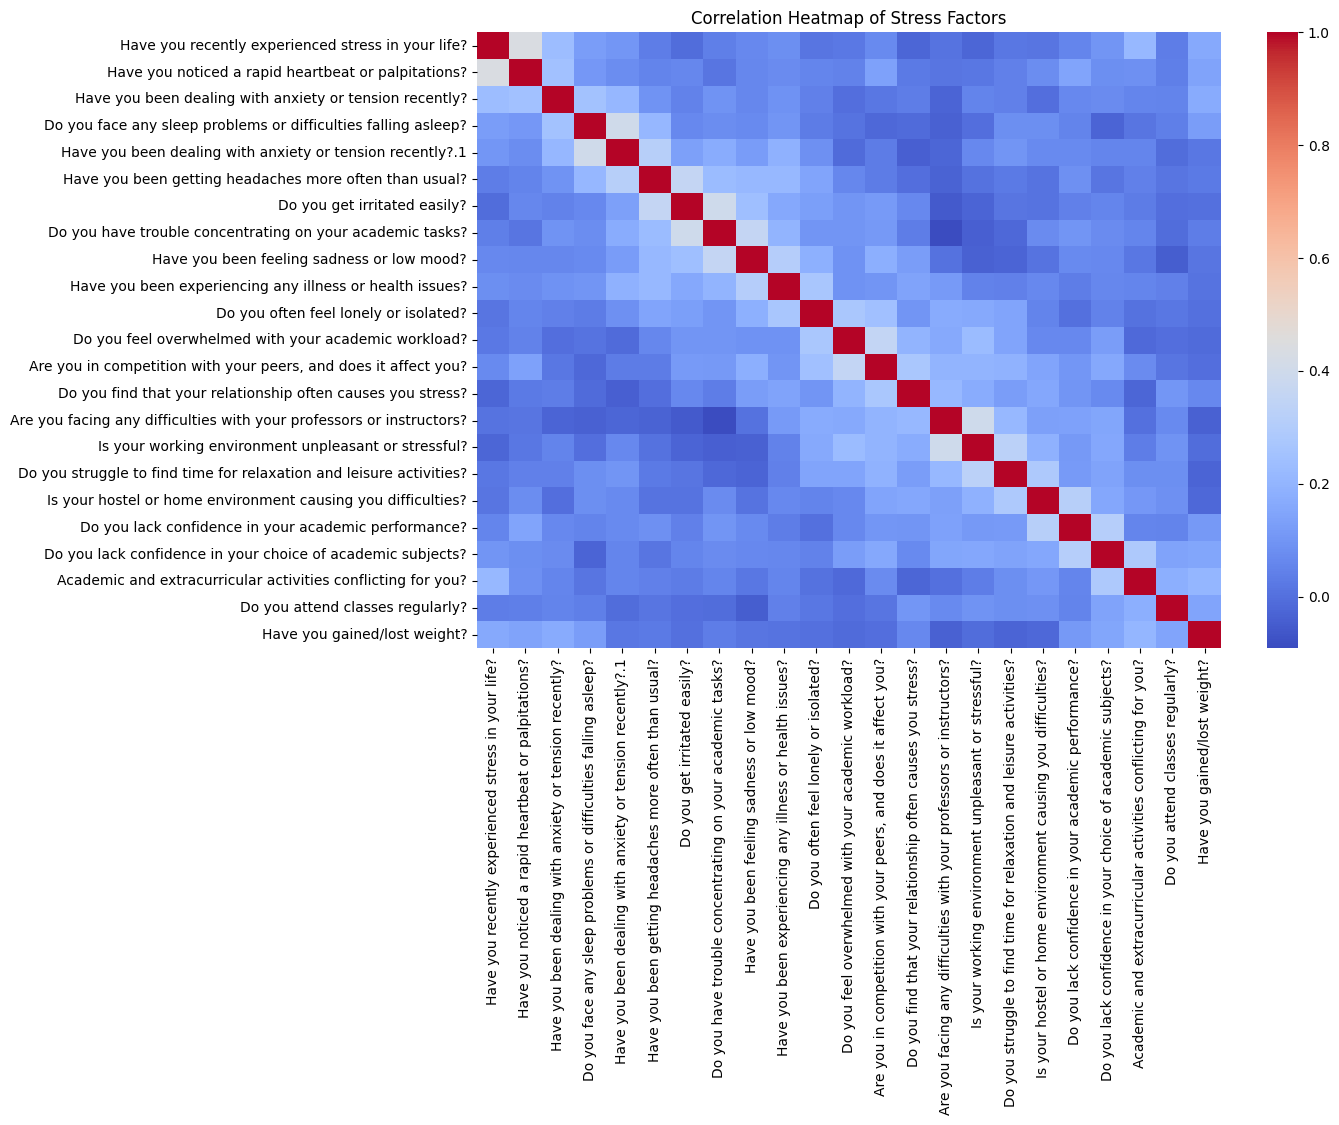

In [76]:
plt.figure(figsize=(12,8))
sns.heatmap(stress_df[survey_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Stress Factors")
plt.show()



In [ ]:
# Encode Gender as numeric (0/1)
stress_df["Gender"] = stress_df["Gender"].map({"Male": 0, "Female": 1})

In [ ]:
# Encode Gender (0=Male, 1=Female assumed, but check!)
stress_df["Gender"] = stress_df["Gender"].map({0: "Male", 1: "Female"})

# Encode target (stress type)
le = LabelEncoder()
stress_df["Stress_Type"] = le.fit_transform(stress_df["Which type of stress do you primarily experience?"])

# Features and target
X = stress_df.drop(columns=["Which type of stress do you primarily experience?", "Stress_Type"])
y = stress_df["Stress_Type"]



In [ ]:
# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#

In [ ]:
#Training model
model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

from sklearn.preprocessing import LabelEncoder



Accuracy: 0.9408284023668639

Classification Report:
                                                                                  precision    recall  f1-score   support

Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.       1.00      0.67      0.80         6
   Eustress (Positive Stress) - Stress that motivates and enhances performance.       0.94      1.00      0.97       154
                       No Stress - Currently experiencing minimal to no stress.       1.00      0.11      0.20         9

                                                                       accuracy                           0.94       169
                                                                      macro avg       0.98      0.59      0.66       169
                                                                   weighted avg       0.94      0.94      0.92       169



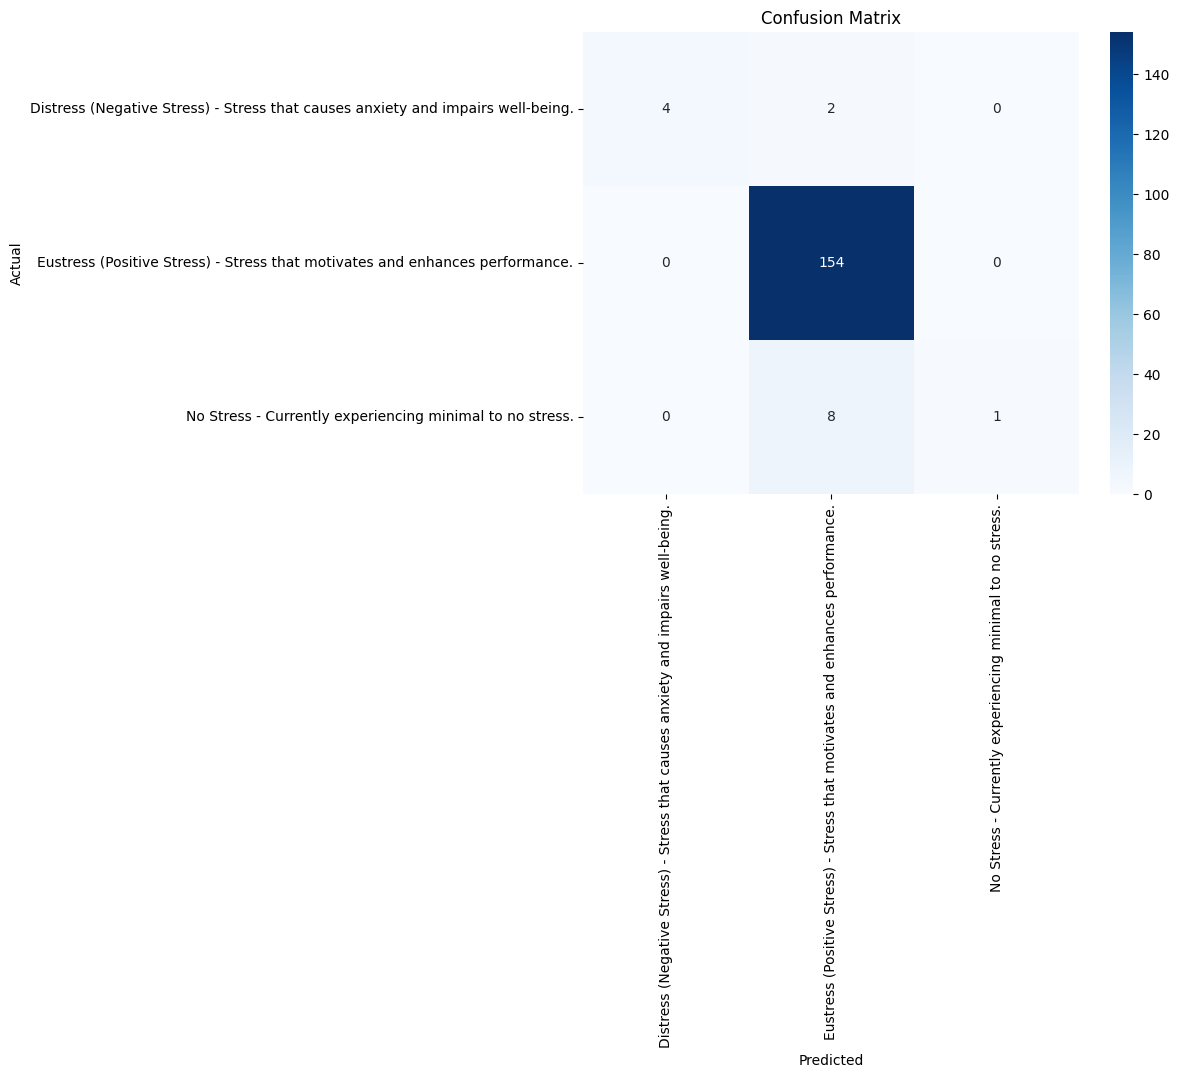

In [ ]:
# Confusion Matrix

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
            xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()




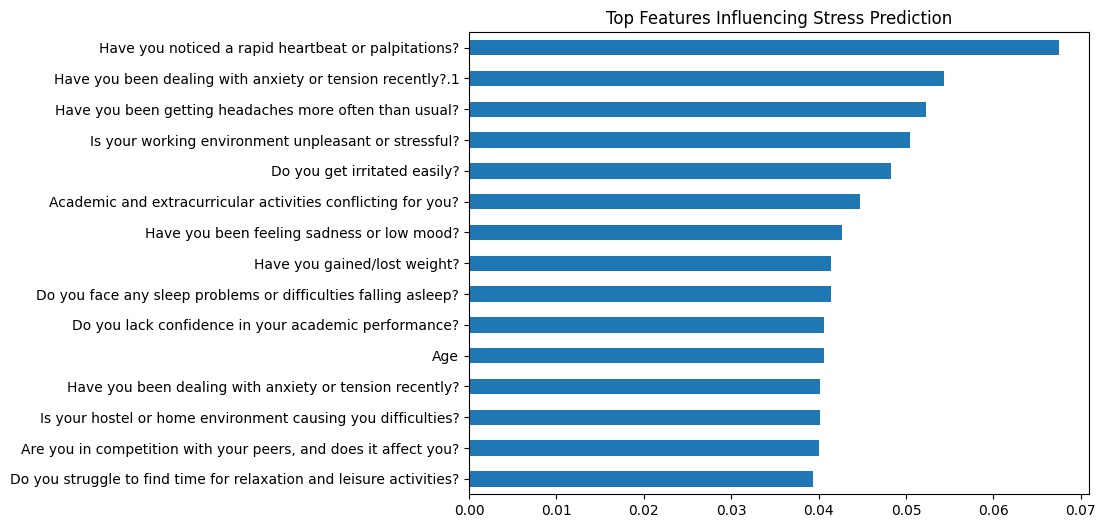

In [ ]:
# Feature Importance

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(kind="barh", figsize=(8,6))
plt.title("Top Features Influencing Stress Prediction")
plt.show()


In [ ]:
# Hyperparameter Tuning (Optional)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)





Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV Score: 0.9273015873015874


In [ ]:
# Model deployment

import joblib
joblib.dump(model, "stress_prediction_model.pkl")



['stress_prediction_model.pkl']